## Load data & setup:

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_d")

#Load the dataset
df = pd.read_csv('../data/raw/energy_raw.csv')


In [ ]:

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')
df=df.sort_values("date").reset_index(drop=True)
print("Data loaded successfully!")
print("Dataset shape:", df.shape)
print("Data Range:", df['date'].min(), "to", df['date'].max())
df.head()





Data loaded successfully!
Dataset shape: (19735, 29)
Data Range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00


,date,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Appliances
0,2016-01-11 17:00:00,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,60
1,2016-01-11 17:10:00,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,60
2,2016-01-11 17:20:00,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,50
3,2016-01-11 17:30:00,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,50
4,2016-01-11 17:40:00,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,60


## Before-snapshot

In [22]:
print("="*55)
print("BEFORE PREPROCESSING SNAPSHOT (DS401 Requirement)")
print("="*55)

print(f"\nShape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\nTarget variable stats:")
print(df['Appliances'].describe().round(2))

# Save snapshot for report
snapshot = df.describe().round(2)
snapshot.to_csv('../outputs/before_preprocessing_snapshot.csv')
print("\nSnapshot saved to outputs/")


BEFORE PREPROCESSING SNAPSHOT (DS401 Requirement)

Shape: (19735, 29)

Missing values:
date           0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
Appliances     0
dtype: int64

Duplicates: 0

Target variable stats:
count    19735.00
mean        97.69
std        102.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max       1080.00
Name: Appliances, dtype: float64

Snapshot saved to outputs/


## Energy consumption over time:

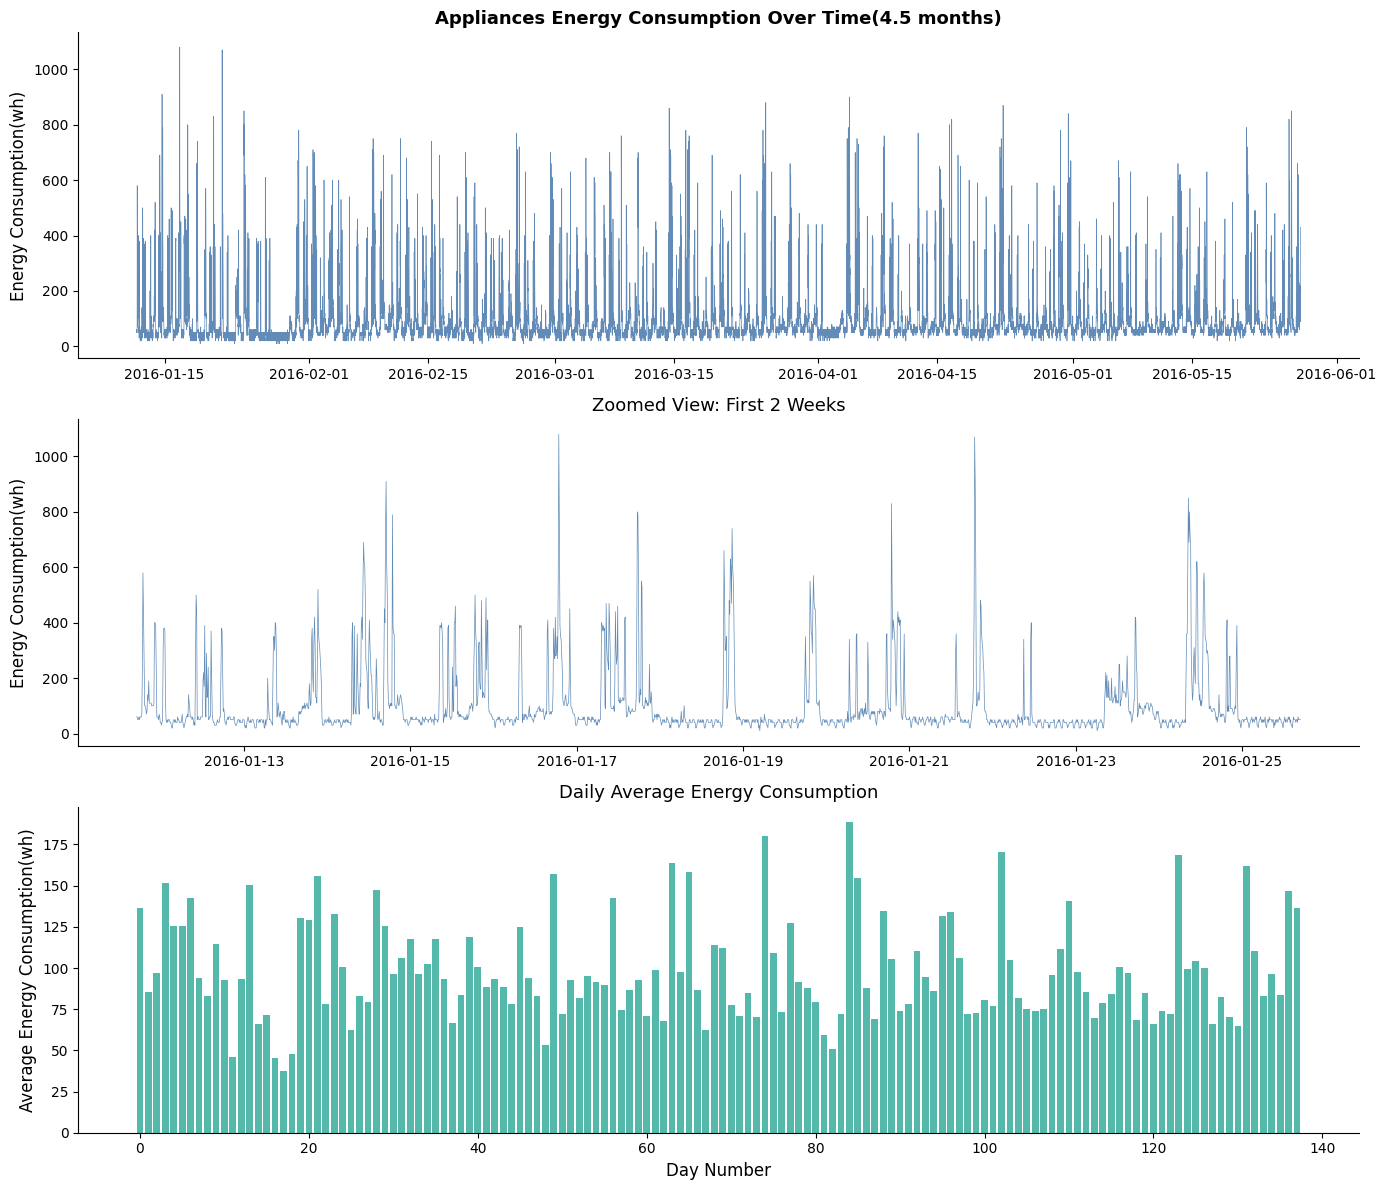

In [23]:
fig,axis=plt.subplots(3,1,figsize=(14,12))

#full time series
axis[0].plot(df['date'], df['Appliances'],alpha=0.7,color='#1F5C99',linewidth=0.5)
axis[0].set_title('Appliances Energy Consumption Over Time(4.5 months)', fontsize=13,fontweight='bold')
axis[0].set_xlabel('', fontsize=12)
axis[0].set_ylabel('Energy Consumption(wh)', fontsize=12)

#zoomed 2weeks
two_weeks = df[df['date'] < df['date'].min() + pd.Timedelta(weeks=2)]
axis[1].plot(two_weeks['date'], two_weeks['Appliances'],alpha=0.7,color='#1F5C99',linewidth=0.5)
axis[1].set_title('Zoomed View: First 2 Weeks', fontsize=13)
axis[1].set_xlabel('', fontsize=12)
axis[1].set_ylabel('Energy Consumption(wh)', fontsize=12)

#Daily average
df["day"]=df['date'].dt.date
daily_avg = df.groupby('day')['Appliances'].mean()
axis[2].bar(range(len(daily_avg)), daily_avg.values,alpha=0.7,color="#0B9B88",linewidth=0.5)
axis[2].set_title('Daily Average Energy Consumption', fontsize=13)
axis[2].set_xlabel('Day Number', fontsize=12)
axis[2].set_ylabel('Average Energy Consumption(wh)', fontsize=12)

plt.tight_layout()
plt.savefig('../outputs/figures/01energy_consumption_over_time.png')


 ## Hourly & weekday patterns:

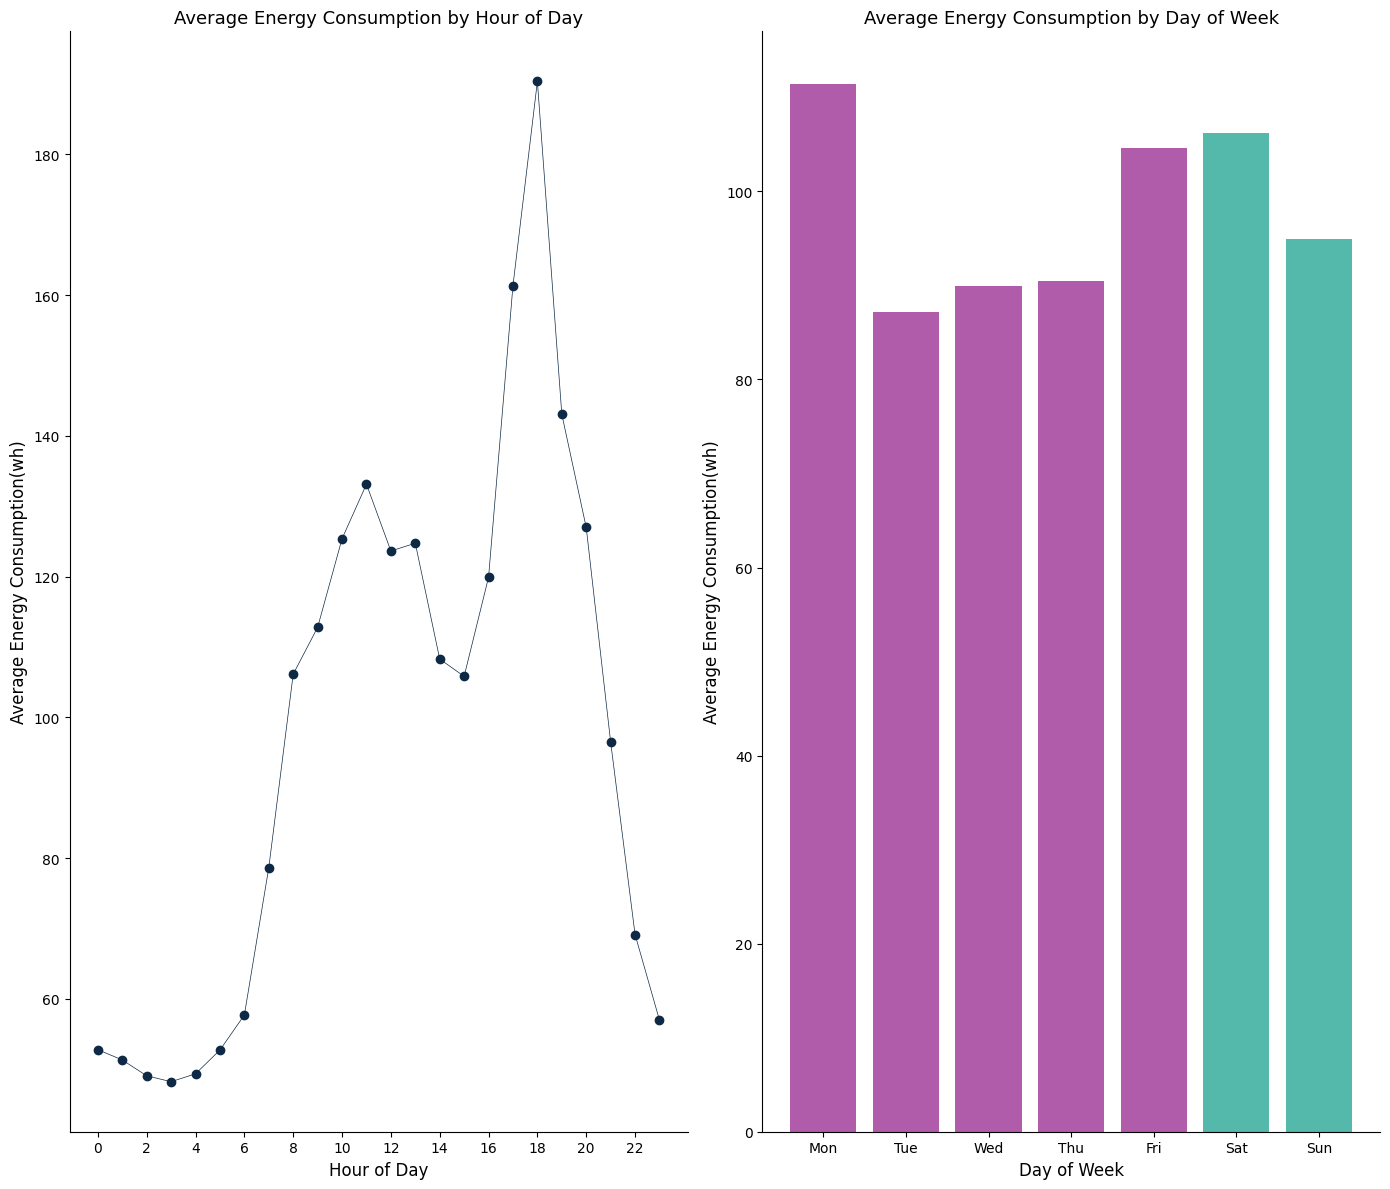

In [24]:
df["Hour"] = df['date'].dt.hour
df["day_of_week"] = df['date'].dt.day_name()
df["month"]=df['date'].dt.month
fig, axis = plt.subplots(1, 2, figsize=(14, 12))

average_by_hour = df.groupby('Hour')['Appliances'].mean()
axis[0].plot(average_by_hour.index, average_by_hour.values, marker='o', color="#0D2945",linewidth=0.5)
axis[0].set_title('Average Energy Consumption by Hour of Day', fontsize=13)
axis[0].set_xlabel('Hour of Day', fontsize=12)
axis[0].set_ylabel('Average Energy Consumption(wh)', fontsize=12)
axis[0].set_xticks(range(0, 24,2))

order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
average_weekday = df.groupby('day_of_week')['Appliances'].mean().reindex(order)
colors=["#911588"if d not in ['Saturday', 'Sunday'] else "#0B9B88" for d in order]
axis[1].bar(range(7), average_weekday.values, color=colors,alpha=0.7,linewidth=0.5)
axis[1].set_title('Average Energy Consumption by Day of Week', fontsize=13)
axis[1].set_xlabel('Day of Week', fontsize=12)
axis[1].set_ylabel('Average Energy Consumption(wh)', fontsize=12)
axis[1].set_xticks(range(7))
axis[1].set_xticklabels([d[:3] for d in order])

plt.tight_layout()
plt.savefig('../outputs/figures/02hourly_and_weekly_patterns.png')
plt.show()

## Heatmap: hour vs weekday:

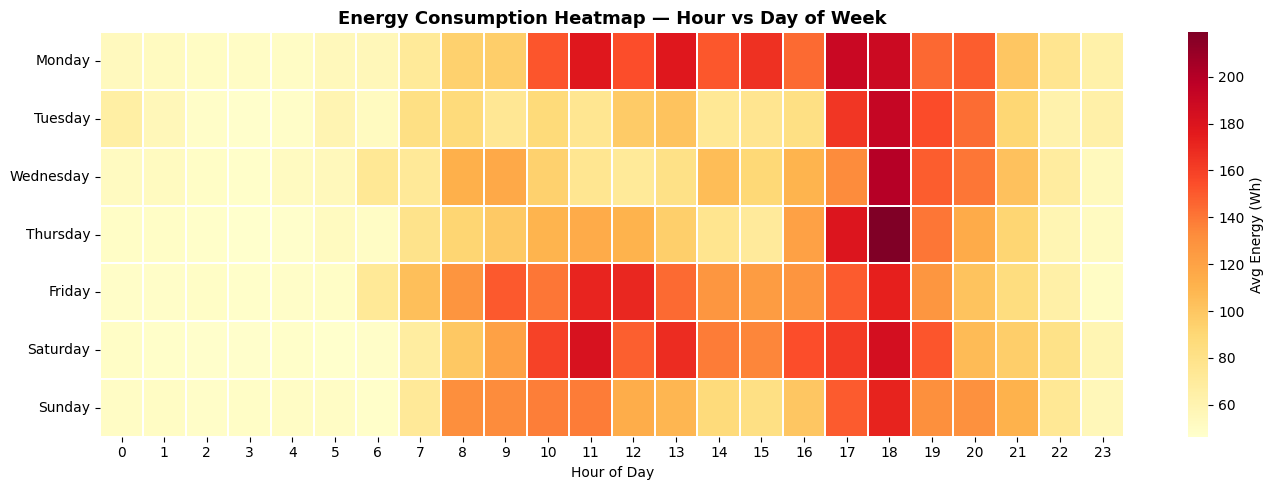

Key insight: Spot the peak hours and weekend vs weekday differences!


In [25]:
pivot = df.pivot_table(values='Appliances', index='day_of_week', columns='Hour', aggfunc='mean')
pivot = pivot.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, annot=False, fmt='.0f',
            cbar_kws={'label': 'Avg Energy (Wh)'})
plt.title('Energy Consumption Heatmap — Hour vs Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../outputs/figures/03_heatmap_hour_weekday.png', bbox_inches='tight')
plt.show()
print("Key insight: Spot the peak hours and weekend vs weekday differences!")


## Target variable distribution:

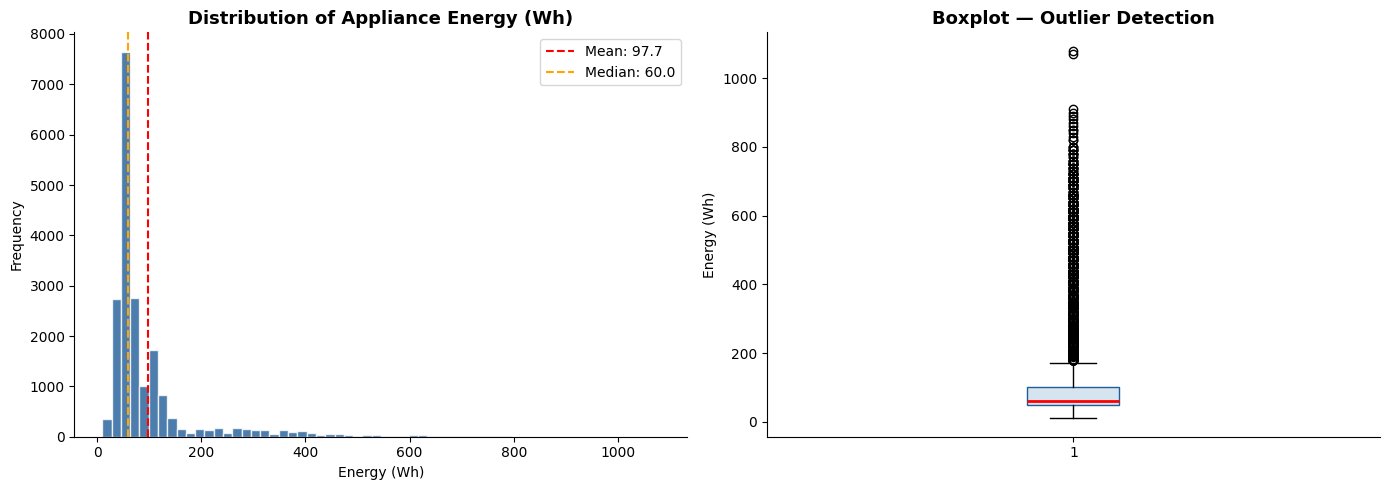

Outliers detected: 2138 rows (10.8%)


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Appliances'], bins=60, color='#1F5C99', alpha=0.8, edgecolor='white')
axes[0].set_title('Distribution of Appliance Energy (Wh)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Energy (Wh)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Appliances'].mean(), color='red', linestyle='--', label=f"Mean: {df['Appliances'].mean():.1f}")
axes[0].axvline(df['Appliances'].median(), color='orange', linestyle='--', label=f"Median: {df['Appliances'].median():.1f}")
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Appliances'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#D6E4F0', color='#1F5C99'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — Outlier Detection', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Energy (Wh)')

plt.tight_layout()
plt.savefig('../outputs/figures/04_target_distribution.png', bbox_inches='tight')
plt.show()

# Calculate outlier count
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Appliances'] < Q1 - 1.5*IQR) | (df['Appliances'] > Q3 + 1.5*IQR)]
print(f"Outliers detected: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)")

## Correlation heatmap:

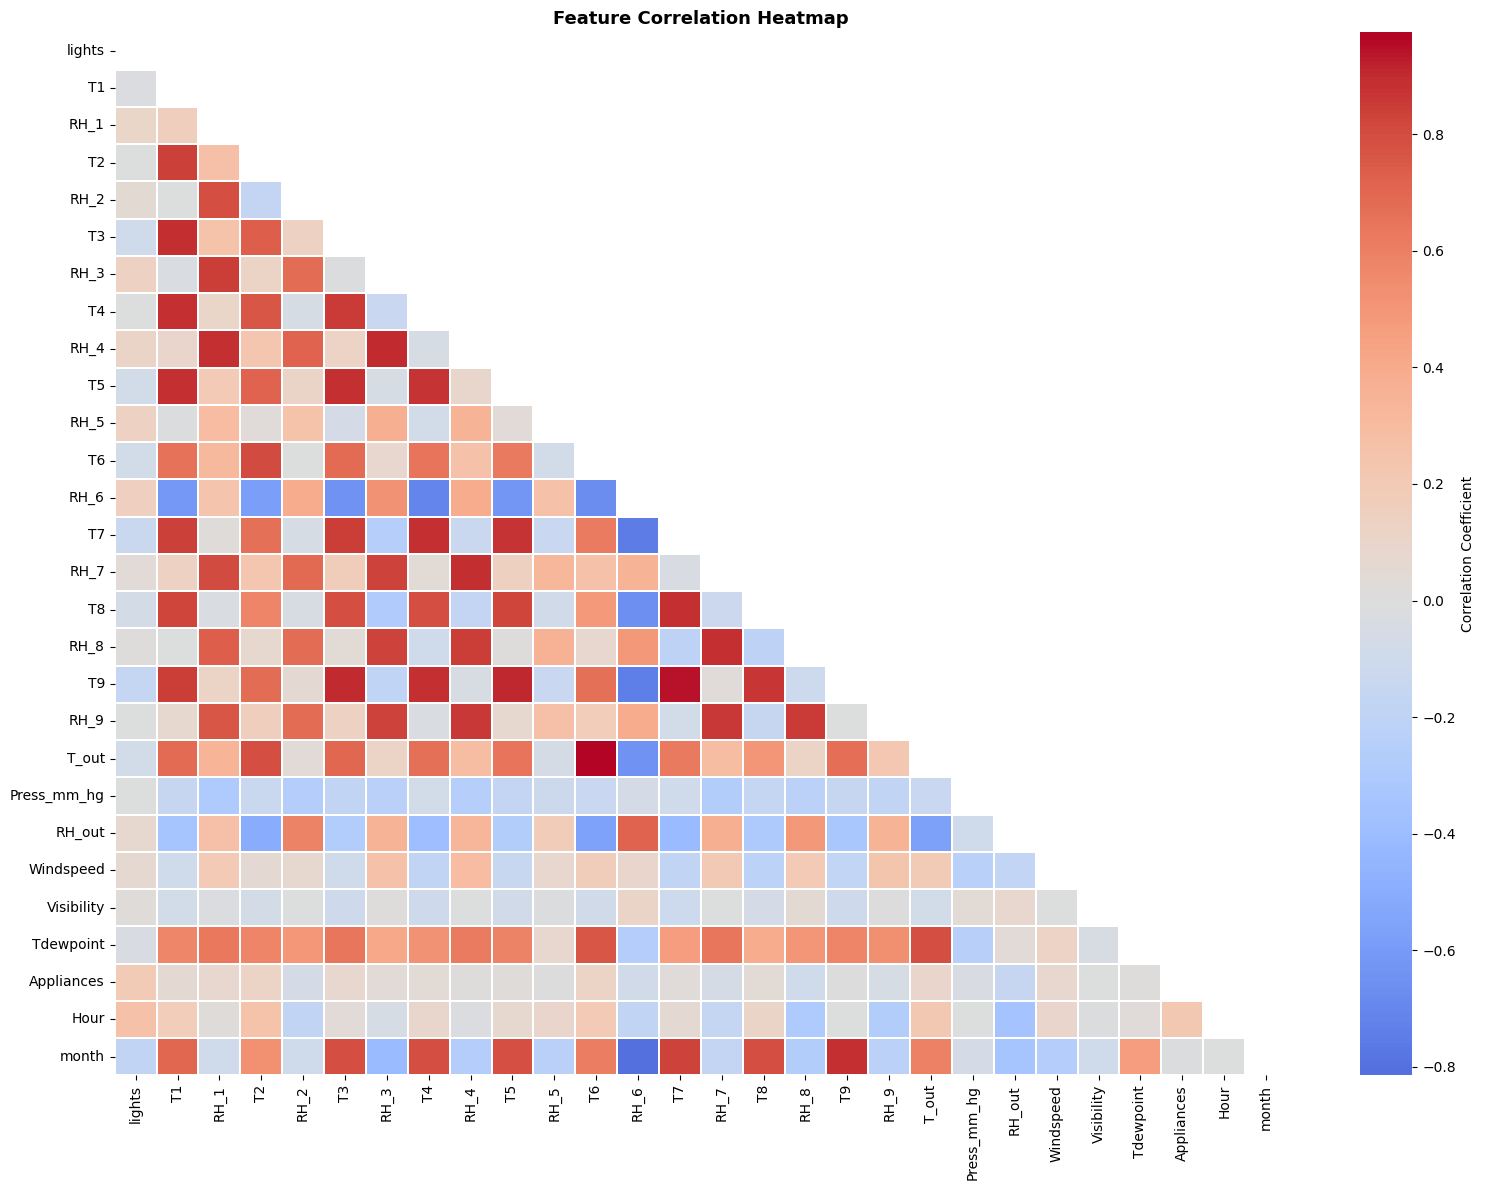

In [28]:
# Drop non-numeric and noise columns for correlation
corr_df = df.drop(columns=['date', 'day', 'rv1', 'rv2','day_of_week'], errors='ignore')

plt.figure(figsize=(16, 12))
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## Top features correlated with target:

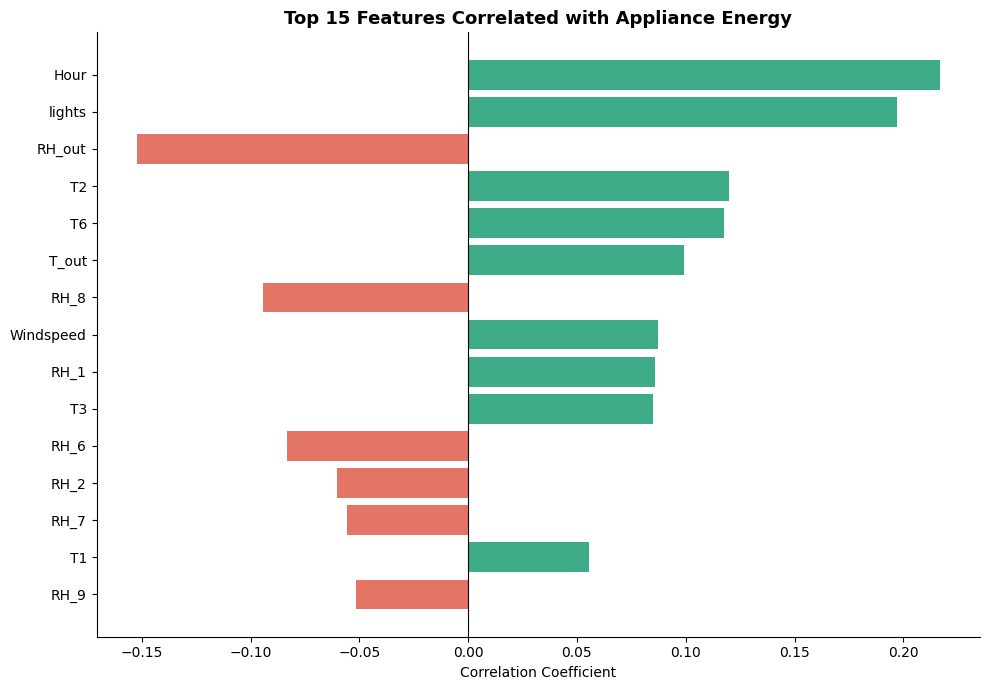

Top 5 most correlated features:
Hour      0.217
lights    0.197
RH_out   -0.152
T2        0.120
T6        0.118


In [29]:
target_corr = corr_df.corr()['Appliances'].drop('Appliances').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#1D9E75' if v > 0 else '#E05C4B' for v in target_corr.values[:15]]
plt.barh(target_corr.index[:15], target_corr.values[:15], color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Features Correlated with Appliance Energy', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/figures/06_top_correlations.png', bbox_inches='tight')
plt.show()

print("Top 5 most correlated features:")
print(target_corr.head().round(3).to_string())

## EDA Summary:

In [31]:
print("="*55)
print("EDA SUMMARY — KEY FINDINGS")
print("="*55)

print(f"""
1. Dataset: {df.shape[0]:,} rows, {df.shape[1]} columns
   Date range: {df['date'].min().date()} to {df['date'].max().date()}

2. Target (Appliances):
   Mean:   {df['Appliances'].mean():.1f} Wh
   Median: {df['Appliances'].median():.1f} Wh
   Max:    {df['Appliances'].max():.1f} Wh
   Outliers: {len(outliers)} rows ({len(outliers)/len(df)*100:.1f}%)

3. Peak usage hours: typically 8–10 AM and 6–9 PM
4. Weekends show higher variability than weekdays
5. Right-skewed distribution → log transform may help
6. No missing values found 
7. rv1, rv2 are noise columns → will be dropped in Phase 3

Figures saved to: outputs/figures/

""")

EDA SUMMARY — KEY FINDINGS

1. Dataset: 19,735 rows, 33 columns
   Date range: 2016-01-11 to 2016-05-27

2. Target (Appliances):
   Mean:   97.7 Wh
   Median: 60.0 Wh
   Max:    1080.0 Wh
   Outliers: 2138 rows (10.8%)

3. Peak usage hours: typically 8–10 AM and 6–9 PM
4. Weekends show higher variability than weekdays
5. Right-skewed distribution → log transform may help
6. No missing values found 
7. rv1, rv2 are noise columns → will be dropped in Phase 3

Figures saved to: outputs/figures/


